# Лабораторная работа 5

**Тема:** обучение на основе временных различий.

Среда: `CartPole-v1` из Gymnasium. Для табличных методов непрерывное состояние дискретизируется по корзинам.

In [1]:
import importlib.util
import subprocess
import sys


def ensure(package, import_name=None):
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

for package, import_name in [('numpy', 'numpy'), ('matplotlib', 'matplotlib'), ('gymnasium', 'gymnasium'), ('pandas', 'pandas')]:
    ensure(package, import_name)

import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gymnasium as gym

ENV_NAME = 'CartPole-v1'
RANDOM_STATE = 42

In [2]:
bins = [
    np.linspace(-2.4, 2.4, 3)[1:-1],
    np.linspace(-3.0, 3.0, 3)[1:-1],
    np.linspace(-0.2095, 0.2095, 9)[1:-1],
    np.linspace(-3.0, 3.0, 9)[1:-1],
]
state_shape = tuple(len(b) + 1 for b in bins)
n_actions = 2


def discretize_observation(obs):
    clipped = np.clip(obs, [-2.4, -3.0, -0.2095, -3.0], [2.4, 3.0, 0.2095, 3.0])
    return tuple(int(np.digitize(clipped[i], bins[i])) for i in range(4))


def epsilon_greedy(q_values, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))
    return int(np.argmax(q_values[state]))


def moving_average(values, window=25):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode='valid')

state_shape, np.prod(state_shape)

((2, 2, 8, 8), np.int64(256))

In [3]:
def train_sarsa(episodes=1500, alpha=0.18, gamma=0.99):
    env = gym.make(ENV_NAME)
    rng = np.random.default_rng(RANDOM_STATE)
    q = np.zeros(state_shape + (n_actions,))
    rewards = []
    started = time.perf_counter()

    for episode in range(episodes):
        obs, _ = env.reset(seed=1000 + episode)
        state = discretize_observation(obs)
        epsilon = max(0.02, np.exp(-episode / 500))
        action = epsilon_greedy(q, state, epsilon, rng)
        total_reward = 0.0

        for _ in range(500):
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize_observation(next_obs)
            next_action = epsilon_greedy(q, next_state, epsilon, rng)
            target = reward if done else reward + gamma * q[next_state + (next_action,)]
            q[state + (action,)] += alpha * (target - q[state + (action,)])
            state, action = next_state, next_action
            total_reward += reward
            if done:
                break
        rewards.append(total_reward)

    env.close()
    return {'name': 'SARSA', 'q': q, 'rewards': rewards, 'time_sec': time.perf_counter() - started}

In [4]:
def train_q_learning(episodes=1500, alpha=0.18, gamma=0.99):
    env = gym.make(ENV_NAME)
    rng = np.random.default_rng(RANDOM_STATE + 1)
    q = np.zeros(state_shape + (n_actions,))
    rewards = []
    started = time.perf_counter()

    for episode in range(episodes):
        obs, _ = env.reset(seed=2000 + episode)
        state = discretize_observation(obs)
        epsilon = max(0.02, np.exp(-episode / 500))
        total_reward = 0.0

        for _ in range(500):
            action = epsilon_greedy(q, state, epsilon, rng)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize_observation(next_obs)
            target = reward if done else reward + gamma * np.max(q[next_state])
            q[state + (action,)] += alpha * (target - q[state + (action,)])
            state = next_state
            total_reward += reward
            if done:
                break
        rewards.append(total_reward)

    env.close()
    return {'name': 'Q-learning', 'q': q, 'rewards': rewards, 'time_sec': time.perf_counter() - started}

In [5]:
def train_double_q_learning(episodes=1500, alpha=0.18, gamma=0.99):
    env = gym.make(ENV_NAME)
    rng = np.random.default_rng(RANDOM_STATE + 2)
    q1 = np.zeros(state_shape + (n_actions,))
    q2 = np.zeros_like(q1)
    rewards = []
    started = time.perf_counter()

    for episode in range(episodes):
        obs, _ = env.reset(seed=3000 + episode)
        state = discretize_observation(obs)
        epsilon = max(0.02, np.exp(-episode / 500))
        total_reward = 0.0

        for _ in range(500):
            action = epsilon_greedy(q1 + q2, state, epsilon, rng)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize_observation(next_obs)

            if rng.random() < 0.5:
                best = int(np.argmax(q1[next_state]))
                target = reward if done else reward + gamma * q2[next_state + (best,)]
                q1[state + (action,)] += alpha * (target - q1[state + (action,)])
            else:
                best = int(np.argmax(q2[next_state]))
                target = reward if done else reward + gamma * q1[next_state + (best,)]
                q2[state + (action,)] += alpha * (target - q2[state + (action,)])

            state = next_state
            total_reward += reward
            if done:
                break
        rewards.append(total_reward)

    env.close()
    return {'name': 'Double Q-learning', 'q': q1 + q2, 'rewards': rewards, 'time_sec': time.perf_counter() - started}

In [6]:
results = [train_sarsa(), train_q_learning(), train_double_q_learning()]
summary = []
for result in results:
    rewards = np.array(result['rewards'])
    summary.append({
        'algorithm': result['name'],
        'mean_reward_last_50': rewards[-50:].mean(),
        'best_reward': rewards.max(),
        'time_sec': result['time_sec'],
    })

import pandas as pd
pd.DataFrame(summary).round(2)

,algorithm,mean_reward_last_50,best_reward,time_sec
0,SARSA,207.34,500.0,3.68
1,Q-learning,212.44,500.0,3.72
2,Double Q-learning,282.86,500.0,3.30


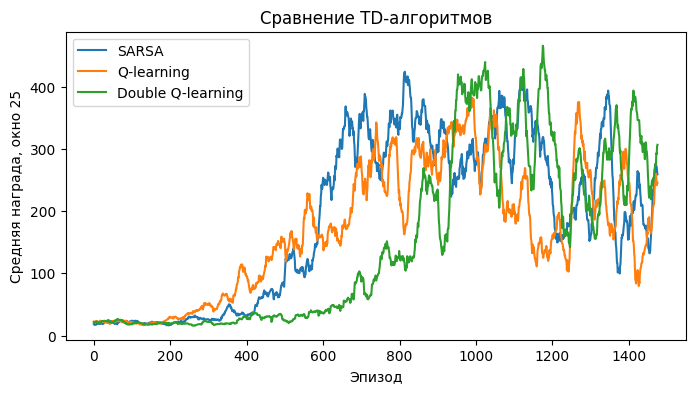

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for result in results:
    ma = moving_average(result['rewards'], window=25)
    ax.plot(np.arange(len(ma)), ma, label=result['name'])
ax.set_xlabel('Эпизод')
ax.set_ylabel('Средняя награда, окно 25')
ax.set_title('Сравнение TD-алгоритмов')
ax.legend()
plt.show()

In [8]:
def evaluate_policy(q_values, episodes=20):
    env = gym.make(ENV_NAME)
    rewards = []
    for episode in range(episodes):
        obs, _ = env.reset(seed=5000 + episode)
        state = discretize_observation(obs)
        total = 0.0
        for _ in range(500):
            action = int(np.argmax(q_values[state]))
            obs, reward, terminated, truncated, _ = env.step(action)
            state = discretize_observation(obs)
            total += reward
            if terminated or truncated:
                break
        rewards.append(total)
    env.close()
    return np.mean(rewards), np.std(rewards)

evaluation = []
for result in results:
    mean_score, std_score = evaluate_policy(result['q'])
    evaluation.append({'algorithm': result['name'], 'eval_mean': mean_score, 'eval_std': std_score})

pd.DataFrame(evaluation).round(2)

,algorithm,eval_mean,eval_std
0,SARSA,125.75,19.83
1,Q-learning,293.95,71.72
2,Double Q-learning,199.80,148.55
